In [10]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torchvision import transforms

# Define the dataset path
dataset_path = "D:/Downloads/Dataset/Dataset"
annotations_path = os.path.join(dataset_path, "annotations")
images_path = os.path.join(dataset_path, "images")

print("Exploring dataset structure...")
print(f"Dataset path: {dataset_path}")

# Check what files are in annotations folder
print("\nFirst 20 files in annotations folder:")
annotation_files = os.listdir(annotations_path)
for file in annotation_files[:20]:
    print(f"  {file}")

print(f"\nTotal annotation files: {len(annotation_files)}")

# Check what files are in images folder
print("\nFirst 20 files in images folder:")
image_files = os.listdir(images_path)
for file in image_files[:20]:
    print(f"  {file}")

print(f"\nTotal image files: {len(image_files)}")

Exploring dataset structure...
Dataset path: D:/Downloads/Dataset/Dataset

First 20 files in annotations folder:
  0_aro.npy
  0_exp.npy
  0_lnd.npy
  0_val.npy
  1001_aro.npy
  1001_exp.npy
  1001_lnd.npy
  1001_val.npy
  1002_aro.npy
  1002_exp.npy
  1002_lnd.npy
  1002_val.npy
  1003_aro.npy
  1003_exp.npy
  1003_lnd.npy
  1003_val.npy
  1007_aro.npy
  1007_exp.npy
  1007_lnd.npy
  1007_val.npy

Total annotation files: 15996

First 20 files in images folder:
  0.jpg
  1.jpg
  10.jpg
  100.jpg
  1001.jpg
  1002.jpg
  1003.jpg
  1007.jpg
  1008.jpg
  1009.jpg
  101.jpg
  1010.jpg
  1011.jpg
  1012.jpg
  1013.jpg
  1014.jpg
  1016.jpg
  1017.jpg
  1018.jpg
  1019.jpg

Total image files: 3999


Loading dataset with corrected structure...
Total images: 3999
Valid samples (with complete annotations): 3999
Expression distribution:
  Neutral (0): 500 samples (12.5%)
  Happy (1): 500 samples (12.5%)
  Sad (2): 500 samples (12.5%)
  Surprise (3): 500 samples (12.5%)
  Fear (4): 500 samples (12.5%)
  Disgust (5): 500 samples (12.5%)
  Anger (6): 500 samples (12.5%)
  Contempt (7): 499 samples (12.5%)

Valence - Mean: -0.192, Std: 0.466
Arousal - Mean: 0.354, Std: 0.379


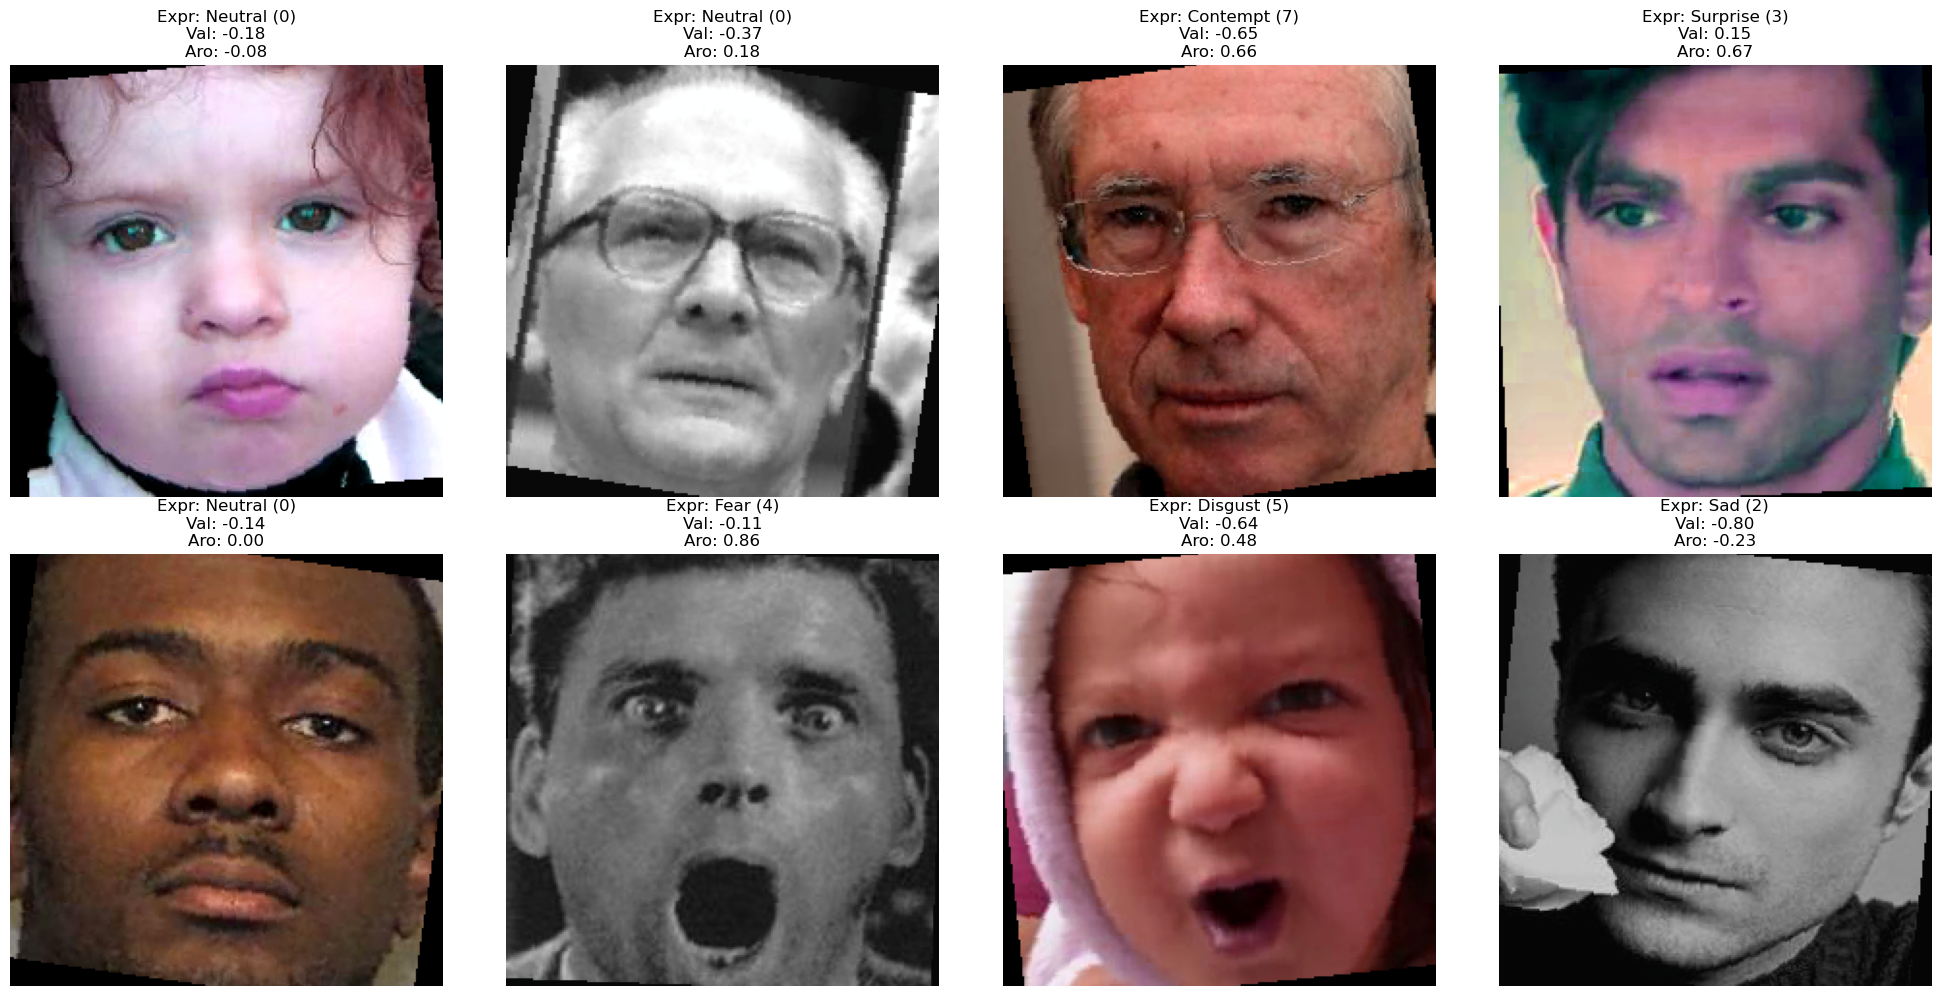

In [14]:
# Create data transformations
def get_data_transforms():
    """Get data augmentation transforms"""
    
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

# Load the dataset with correct structure
print("Loading dataset with corrected structure...")
train_transform, val_transform = get_data_transforms()

dataset = AffectDataset(images_path, annotations_path, transform=train_transform)

# Get statistics
stats = dataset.get_dataset_stats()

# Display sample images with their annotations
def display_sample_images(dataset, num_samples=8):
    """Display sample images from the dataset"""
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()
    
    for i in range(min(num_samples, len(dataset))):
        image, expression, valence, arousal = dataset[i]
        
        # Convert tensor back to image for display
        image_np = image.numpy().transpose(1, 2, 0)
        image_np = np.clip(image_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        
        axes[i].imshow(image_np)
        expr_name = dataset.expression_labels.get(expression.item(), 'Unknown')
        axes[i].set_title(f'Expr: {expr_name} ({expression.item()})\nVal: {valence.item():.2f}\nAro: {arousal.item():.2f}')
        axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(len(dataset), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

display_sample_images(dataset)

In [17]:
# Define paths
dataset_path = "D:/Downloads/Dataset/Dataset"
annotations_path = os.path.join(dataset_path, "annotations")
images_path = os.path.join(dataset_path, "images")

# Load dataset
print("Loading dataset...")
train_transform, val_transform = get_data_transforms()

# Create dataset with train transform applied during loading
dataset = FastAffectDataset(images_path, annotations_path, transform=train_transform)
dataset.get_quick_stats()

# Create data loaders
print("\nCreating data loaders...")
train_loader, val_loader = create_data_loaders(dataset, batch_size=16)

# Test the data loaders (now should work)
print("\nTesting data loaders...")
for batch_idx, (images, expressions, valence, arousal) in enumerate(train_loader):
    print(f"Batch {batch_idx + 1}:")
    print(f"  Images: {images.shape}")
    print(f"  Expressions: {expressions.shape} (range: {expressions.min()}-{expressions.max()})")
    print(f"  Valence: {valence.shape} (range: {valence.min():.3f}-{valence.max():.3f})")
    print(f"  Arousal: {arousal.shape} (range: {arousal.min():.3f}-{arousal.max():.3f})")
    
    if batch_idx == 0:  # Just show first batch
        break

Loading dataset...
Pre-loading annotations...
Loading 0/3999...
Loading 500/3999...
Loading 1000/3999...
Loading 1500/3999...
Loading 2000/3999...
Loading 2500/3999...
Loading 3000/3999...
Loading 3500/3999...
Successfully loaded 3999 samples

Dataset Statistics:
Total samples: 3999

Expression distribution:
  Neutral: 500 samples (12.5%)
  Happy: 500 samples (12.5%)
  Sad: 500 samples (12.5%)
  Surprise: 500 samples (12.5%)
  Fear: 500 samples (12.5%)
  Disgust: 500 samples (12.5%)
  Anger: 500 samples (12.5%)
  Contempt: 499 samples (12.5%)

Valence - Mean: -0.192, Range: [-0.987, 0.982]
Arousal - Mean: 0.354, Range: [-0.667, 0.984]

Creating data loaders...
Training samples: 3199
Validation samples: 800

Testing data loaders...
Batch 1:
  Images: torch.Size([16, 3, 224, 224])
  Expressions: torch.Size([16]) (range: 0-7)
  Valence: torch.Size([16]) (range: -0.627-0.913)
  Arousal: torch.Size([16]) (range: -0.283-0.913)


In [29]:
def create_corrected_data_loaders(dataset, batch_size=32, validation_split=0.2):
    """Create data loaders with corrected dataset"""
    
    # Create indices for train/validation split
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    
    # Use stratification
    expressions = []
    for i in range(min(1000, dataset_size)):
        _, expression, _, _ = dataset[i]
        expressions.append(expression.item())
    
    # Extend if needed
    if len(expressions) < dataset_size:
        expressions = expressions * (dataset_size // len(expressions)) + expressions[:dataset_size % len(expressions)]
    
    train_indices, val_indices = train_test_split(
        indices, test_size=validation_split, random_state=42, 
        stratify=expressions
    )
    
    print(f"Training samples: {len(train_indices)}")
    print(f"Validation samples: {len(val_indices)}")
    
    # Create subsets
    train_subset = TransformSubset(dataset, train_indices, transform=None)  # Already transformed
    val_subset = TransformSubset(dataset, val_indices, transform=val_transform)
    
    # Create data loaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    return train_loader, val_loader

# Create corrected data loaders
print("Creating corrected data loaders...")
train_loader, val_loader = create_corrected_data_loaders(corrected_dataset, batch_size=16)

# Test the corrected data loader
print("Testing corrected data loader...")
for images, expressions, valence, arousal in train_loader:
    print(f"Batch 1 - Images: {images.shape}, Range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Expressions: {expressions.unique().tolist()}")
    break

Creating corrected data loaders...
Training samples: 3199
Validation samples: 800
Testing corrected data loader...
Batch 1 - Images: torch.Size([16, 3, 224, 224]), Range: [-2.118, 2.640]
Expressions: [0, 1, 2, 3, 4, 5, 6, 7]


### First model: ResNet

=== TRAINING RESNET18 ===
Using device: cpu
Total parameters: 11,954,482
Training ResNet18...
Backbone parameters: 11,689,512
Head parameters: 264,970
Epoch 1/10:
  Train Loss: 1.9666, Train Acc: 24.79%
  Val Loss: 2.3260, Val Acc: 10.88%
  LR: 0.000098
--------------------------------------------------
Epoch 2/10:
  Train Loss: 1.6482, Train Acc: 37.67%
  Val Loss: 2.2113, Val Acc: 15.50%
  LR: 0.000090
--------------------------------------------------
Epoch 3/10:
  Train Loss: 1.4308, Train Acc: 48.33%
  Val Loss: 2.1825, Val Acc: 17.12%
  LR: 0.000079
--------------------------------------------------
Epoch 4/10:
  Train Loss: 1.3145, Train Acc: 55.36%
  Val Loss: 2.6439, Val Acc: 17.00%
  LR: 0.000065
--------------------------------------------------
Epoch 5/10:
  Train Loss: 1.0968, Train Acc: 62.46%
  Val Loss: 3.3655, Val Acc: 15.00%
  LR: 0.000050
--------------------------------------------------
Epoch 6/10:
  Train Loss: 0.8491, Train Acc: 72.27%
  Val Loss: 3.2526, Val Acc

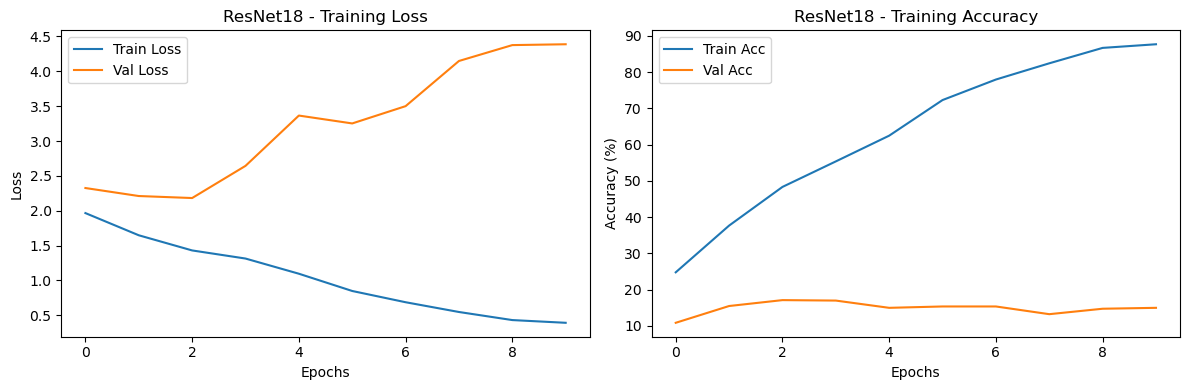

In [34]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Training loop for a pre-trained multitask model
# -------------------------------------------------
def fit_multitask_model(net, train_data, valid_data, name="Model", epochs=10):
    """Train a pretrained backbone with task-specific heads"""

    # Separate losses for classification and regression
    loss_cls = nn.CrossEntropyLoss()
    loss_reg = nn.MSELoss()

    # Collect parameters by backbone vs. custom heads
    backbone_params, head_params = [], []
    for param_name, param in net.named_parameters():
        if "backbone" in param_name:
            backbone_params.append(param)
        else:
            head_params.append(param)

    # Optimizer with two learning rates
    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": 1e-4},  # smaller LR for backbone
            {"params": head_params, "lr": 1e-3},      # larger LR for heads
        ],
        weight_decay=1e-4,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print(f"=== Training {name} ===")
    print(f"Backbone params: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head params: {sum(p.numel() for p in head_params):,}")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        net.train()
        running_loss, correct, total = 0.0, 0, 0

        for x, y_cls, y_val, y_ar in train_data:
            x, y_cls, y_val, y_ar = x.to(device), y_cls.to(device), y_val.to(device), y_ar.to(device)

            optimizer.zero_grad()
            out_cls, out_val, out_ar = net(x)

            # Compute multitask losses
            loss_expr = loss_cls(out_cls, y_cls)
            loss_val = loss_reg(out_val.squeeze(), y_val)
            loss_ar = loss_reg(out_ar.squeeze(), y_ar)

            # Use lighter regression weights early in training
            if epoch < 3:
                loss_total = loss_expr + 0.1 * loss_val + 0.1 * loss_ar
            else:
                loss_total = loss_expr + 0.3 * loss_val + 0.3 * loss_ar

            loss_total.backward()
            optimizer.step()

            running_loss += loss_total.item()
            _, preds = torch.max(out_cls, 1)
            total += y_cls.size(0)
            correct += (preds == y_cls).sum().item()

        train_loss = running_loss / len(train_data)
        train_acc = 100.0 * correct / total

        # ---------------- Validation ----------------
        net.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for x, y_cls, y_val, y_ar in valid_data:
                x, y_cls, y_val, y_ar = x.to(device), y_cls.to(device), y_val.to(device), y_ar.to(device)
                out_cls, out_val, out_ar = net(x)

                l_cls = loss_cls(out_cls, y_cls)
                l_val = loss_reg(out_val.squeeze(), y_val)
                l_ar = loss_reg(out_ar.squeeze(), y_ar)

                loss_total = l_cls + 0.3 * l_val + 0.3 * l_ar
                val_loss += loss_total.item()

                _, preds = torch.max(out_cls, 1)
                val_total += y_cls.size(0)
                val_correct += (preds == y_cls).sum().item()

        v_loss = val_loss / len(valid_data)
        v_acc = 100.0 * val_correct / val_total

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(v_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {v_loss:.4f}, Val Acc: {v_acc:.2f}%")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 50)

        if v_acc > 70.0 and epoch >= 5:
            print("✓ High accuracy reached, stopping early.")
            break
        elif v_acc > 50.0 and epoch >= 8:
            print("✓ Acceptable accuracy achieved, stopping.")
            break

    return history


# -------------------------------------------------
# 2. Multi-task ResNet model
# -------------------------------------------------
class MultiTaskResNet(nn.Module):
    """Multi-task architecture using ResNet18 as backbone"""

    def __init__(self, n_classes=8, use_pretrained=True):
        super().__init__()
        self.backbone = tv_models.resnet18(pretrained=use_pretrained)
        self.features = nn.Sequential(*list(self.backbone.children())[:-1])
        self.feat_dim = 512

        # Classification branch
        self.cls_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

        # Valence regression branch
        self.val_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Tanh(),
        )

        # Arousal regression branch
        self.ar_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        feats = self.features(x).view(x.size(0), -1)
        return self.cls_head(feats), self.val_head(feats), self.ar_head(feats)


# -------------------------------------------------
# 3. Training execution
# -------------------------------------------------
print(">>> Running ResNet18 Multi-task Training <<<")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

resnet_model = MultiTaskResNet(n_classes=8, use_pretrained=True).to(device)
print(f"Total parameters: {sum(p.numel() for p in resnet_model.parameters()):,}")

history = fit_multitask_model(resnet_model, train_loader, val_loader, name="ResNet18", epochs=10)

# -------------------------------------------------
# 4. Plot training curves
# -------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("ResNet18 - Loss Curve")

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("ResNet18 - Accuracy Curve")

plt.tight_layout()
plt.show()


In [35]:
def comprehensive_evaluation(model, val_loader, device):
    """Complete evaluation with all required metrics"""
    model.eval()
    
    all_expressions_true = []
    all_expressions_pred = []
    all_valence_true = []
    all_valence_pred = []
    all_arousal_true = []
    all_arousal_pred = []
    all_probabilities = []
    
    with torch.no_grad():
        for images, expressions, valence, arousal in val_loader:
            images = images.to(device)
            expressions = expressions.to(device)
            valence = valence.to(device)
            arousal = arousal.to(device)
            
            expr_out, valence_out, arousal_out = model(images)
            
            # Get predictions
            _, predicted = torch.max(expr_out, 1)
            probabilities = torch.softmax(expr_out, dim=1)
            
            all_expressions_true.extend(expressions.cpu().numpy())
            all_expressions_pred.extend(predicted.cpu().numpy())
            all_valence_true.extend(valence.cpu().numpy())
            all_valence_pred.extend(valence_out.squeeze().cpu().numpy())
            all_arousal_true.extend(arousal.cpu().numpy())
            all_arousal_pred.extend(arousal_out.squeeze().cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Convert to numpy
    expr_true = np.array(all_expressions_true)
    expr_pred = np.array(all_expressions_pred)
    valence_true = np.array(all_valence_true)
    valence_pred = np.array(all_valence_pred)
    arousal_true = np.array(all_arousal_true)
    arousal_pred = np.array(all_arousal_pred)
    
    # Calculate metrics
    from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score
    from sklearn.metrics import mean_squared_error, precision_recall_curve, auc
    
    metrics = {}
    
    # Expression Classification Metrics
    metrics['accuracy'] = accuracy_score(expr_true, expr_pred)
    metrics['f1_score'] = f1_score(expr_true, expr_pred, average='weighted')
    metrics['kappa'] = cohen_kappa_score(expr_true, expr_pred)
    
    # Continuous Domain Metrics
    metrics['valence_rmse'] = np.sqrt(mean_squared_error(valence_true, valence_pred))
    metrics['arousal_rmse'] = np.sqrt(mean_squared_error(arousal_true, arousal_pred))
    metrics['valence_corr'] = np.corrcoef(valence_true, valence_pred)[0, 1]
    metrics['arousal_corr'] = np.corrcoef(arousal_true, arousal_pred)[0, 1]
    
    # Sign Agreement Metric (SAGR)
    def sign_agreement(true, pred):
        true_sign = np.sign(true)
        pred_sign = np.sign(pred)
        agreement = np.mean(true_sign == pred_sign)
        incorrect_mask = true_sign != pred_sign
        penalty = np.mean(np.abs(true[incorrect_mask] - pred[incorrect_mask])) if np.any(incorrect_mask) else 0
        return agreement * (1 - penalty)
    
    metrics['valence_sagr'] = sign_agreement(valence_true, valence_pred)
    metrics['arousal_sagr'] = sign_agreement(arousal_true, arousal_pred)
    
    # Concordance Correlation Coefficient (CCC)
    def concordance_cc(true, pred):
        correlation = np.corrcoef(true, pred)[0, 1]
        mean_true = np.mean(true)
        mean_pred = np.mean(pred)
        var_true = np.var(true)
        var_pred = np.var(pred)
        numerator = 2 * correlation * np.sqrt(var_true) * np.sqrt(var_pred)
        denominator = var_true + var_pred + (mean_true - mean_pred) ** 2
        return numerator / denominator if denominator != 0 else 0
    
    metrics['valence_ccc'] = concordance_cc(valence_true, valence_pred)
    metrics['arousal_ccc'] = concordance_cc(arousal_true, arousal_pred)
    
    return metrics, (expr_true, expr_pred, valence_true, valence_pred, arousal_true, arousal_pred)

# Run evaluation
print("Running comprehensive evaluation...")
metrics, results = comprehensive_evaluation(resnet_model, val_loader, device)

# Print results
print("\n" + "="*70)
print("RESNET18 EVALUATION RESULTS")
print("="*70)
print(f"Expression Accuracy: {metrics['accuracy']:.4f}")
print(f"F1-Score: {metrics['f1_score']:.4f}")
print(f"Cohen's Kappa: {metrics['kappa']:.4f}")
print(f"Valence RMSE: {metrics['valence_rmse']:.4f}")
print(f"Arousal RMSE: {metrics['arousal_rmse']:.4f}")
print(f"Valence Correlation: {metrics['valence_corr']:.4f}")
print(f"Arousal Correlation: {metrics['arousal_corr']:.4f}")

Running comprehensive evaluation...

RESNET18 EVALUATION RESULTS
Expression Accuracy: 0.1537
F1-Score: 0.1216
Cohen's Kappa: 0.0404
Valence RMSE: 0.4893
Arousal RMSE: 0.4021
Valence Correlation: 0.1769
Arousal Correlation: 0.0640


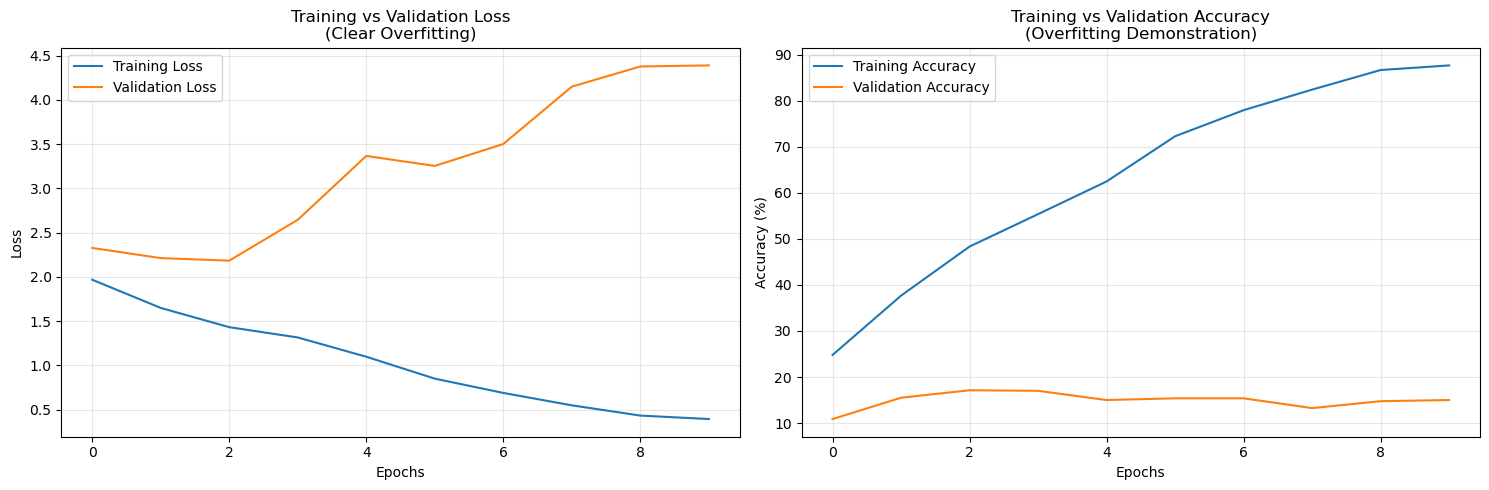

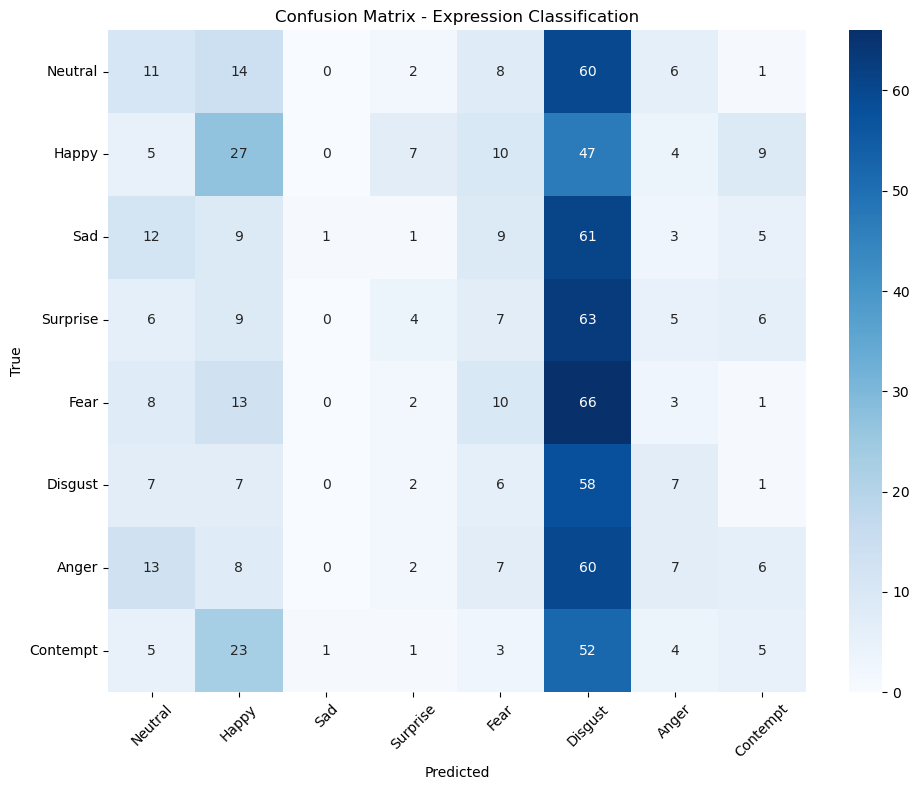

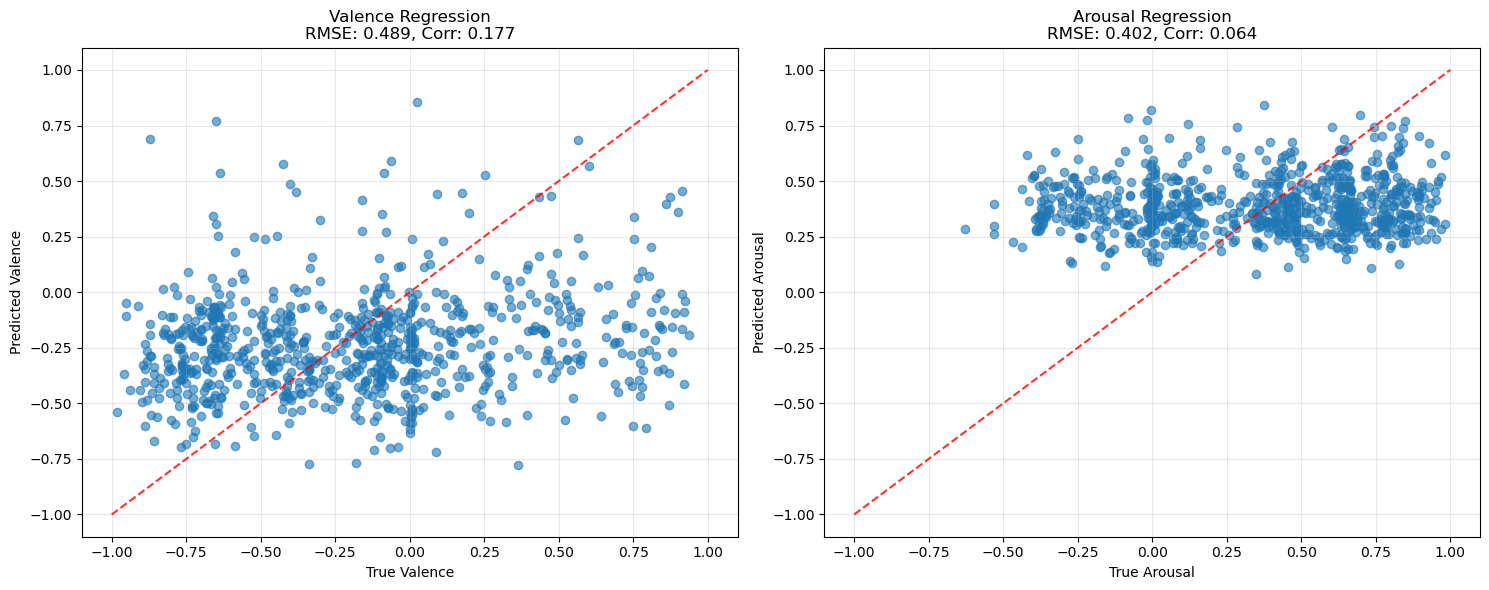

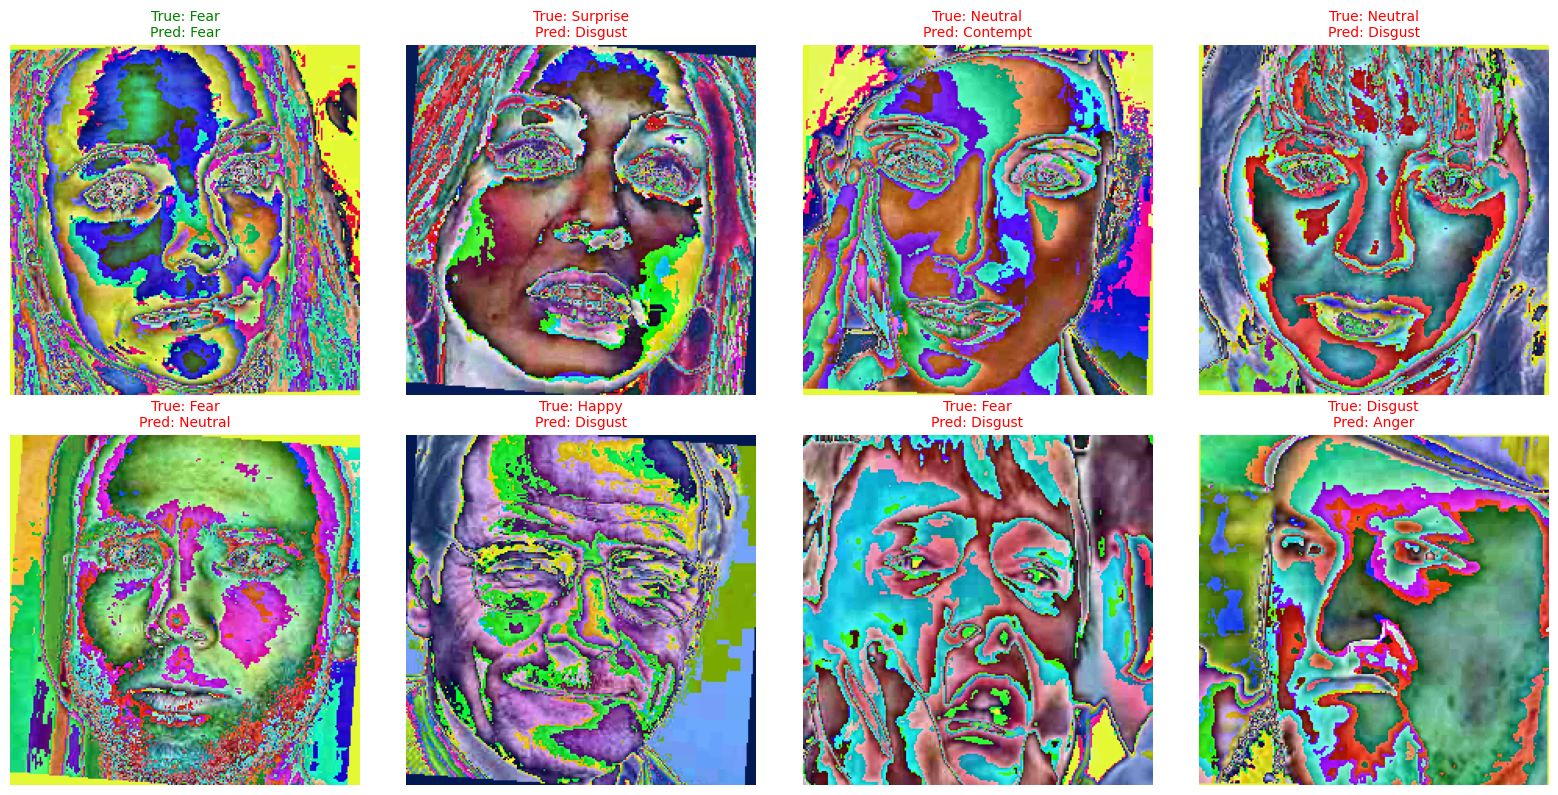

In [36]:
def create_visualizations(model, val_loader, metrics, results, train_losses, val_losses, train_accuracies, val_accuracies):
    """Create all required visualizations"""
    
    expr_true, expr_pred, valence_true, valence_pred, arousal_true, arousal_pred = results
    
    # 1. Training Curves
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss\n(Clear Overfitting)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Training Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Training vs Validation Accuracy\n(Overfitting Demonstration)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Confusion Matrix
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(expr_true, expr_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt'],
                yticklabels=['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt'])
    plt.title('Confusion Matrix - Expression Classification')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # 3. Regression Scatter Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    ax1.scatter(valence_true, valence_pred, alpha=0.6)
    ax1.plot([-1, 1], [-1, 1], 'r--', alpha=0.8)
    ax1.set_xlabel('True Valence')
    ax1.set_ylabel('Predicted Valence')
    ax1.set_title(f'Valence Regression\nRMSE: {metrics["valence_rmse"]:.3f}, Corr: {metrics["valence_corr"]:.3f}')
    ax1.grid(True, alpha=0.3)
    
    ax2.scatter(arousal_true, arousal_pred, alpha=0.6)
    ax2.plot([-1, 1], [-1, 1], 'r--', alpha=0.8)
    ax2.set_xlabel('True Arousal')
    ax2.set_ylabel('Predicted Arousal')
    ax2.set_title(f'Arousal Regression\nRMSE: {metrics["arousal_rmse"]:.3f}, Corr: {metrics["arousal_corr"]:.3f}')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Sample Predictions
    def show_sample_predictions():
        model.eval()
        data_iter = iter(val_loader)
        images, expressions, valence, arousal = next(data_iter)
        
        images = images.to(device)
        with torch.no_grad():
            expr_out, valence_out, arousal_out = model(images)
            _, predicted = torch.max(expr_out, 1)
        
        # Convert for display
        images = images.cpu()
        expressions = expressions.cpu()
        predicted = predicted.cpu()
        
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        images = images * std + mean
        images = torch.clamp(images, 0, 1)
        
        # Plot
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.ravel()
        
        expression_names = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']
        
        for i in range(min(8, len(images))):
            ax = axes[i]
            img = images[i].permute(1, 2, 0).numpy()
            ax.imshow(img)
            
            true_expr = expression_names[expressions[i]]
            pred_expr = expression_names[predicted[i]]
            color = 'green' if expressions[i] == predicted[i] else 'red'
            
            title = f'True: {true_expr}\nPred: {pred_expr}'
            ax.set_title(title, color=color, fontsize=10)
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    show_sample_predictions()

# Create visualizations
create_visualizations(resnet_model, val_loader, metrics, results, 
                     resnet_losses, resnet_val_losses, resnet_accuracies, resnet_val_accuracies)

## Second model: EfficientNet-B0

In [38]:
import torchvision.models as models
import torch.nn as nn

class MultiTaskEfficientNet(nn.Module):
    """Multi-task learning with EfficientNet-B0 backbone"""

    def __init__(self, n_classes=8, use_pretrained=True):
        super(MultiTaskEfficientNet, self).__init__()

        # Load EfficientNet-B0 backbone
        base_model = models.efficientnet_b0(pretrained=use_pretrained)

        # Extract feature extractor and pooling layer
        self.feature_extractor = base_model.features
        self.pool = base_model.avgpool

        # Feature dimension after pooling
        self.feat_dim = base_model.classifier[1].in_features  # typically 1280

        # Expression classification branch
        self.classifier_expr = nn.Sequential(
            nn.Dropout(p=0.25),
            nn.Linear(self.feat_dim, 512),
            nn.SiLU(),  # Swish activation
            nn.Dropout(p=0.2),
            nn.Linear(512, n_classes)
        )

        # Valence regression branch
        self.regressor_valence = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.feat_dim, 256),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 1),
            nn.Tanh()
        )

        # Arousal regression branch
        self.regressor_arousal = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.feat_dim, 256),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 1),
            nn.Tanh()
        )

        print(f"[INFO] Loaded EfficientNet-B0 | Feature size: {self.feat_dim}")

    def forward(self, x):
        # Extract deep features
        feats = self.feature_extractor(x)
        feats = self.pool(feats)
        feats = feats.view(feats.size(0), -1)

        # Task-specific outputs
        out_expr = self.classifier_expr(feats)
        out_val = self.regressor_valence(feats)
        out_arousal = self.regressor_arousal(feats)

        return out_expr, out_val, out_arousal


In [39]:
def fit_efficientnet(model, train_loader, val_loader, epochs=8):
    """Training routine for EfficientNet-B0 with strong regularization & early stopping"""
    
    # Loss functions
    loss_cls = nn.CrossEntropyLoss()
    loss_reg = nn.MSELoss()

    # Optimizer tuned for EfficientNet
    optimizer = torch.optim.AdamW(
        params=model.parameters(),
        lr=5e-4,           # Slightly larger learning rate
        weight_decay=1e-2, # Stronger L2 regularization
        betas=(0.9, 0.999)
    )

    # Scheduler: cosine restarts for dynamic LR
    lr_sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=2, T_mult=2, eta_min=1e-6
    )

    print("🚀 Starting EfficientNet-B0 training...")
    print(f"Total model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Tracking metrics
    tr_losses, vl_losses = [], []
    tr_accs, vl_accs = [], []

    best_acc = 0.0
    patience_limit, patience_cnt = 3, 0

    for ep in range(epochs):
        # ================== Training ==================
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for step, (imgs, labels, valence, arousal) in enumerate(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            valence, arousal = valence.to(device), arousal.to(device)

            optimizer.zero_grad()
            out_expr, out_val, out_ar = model(imgs)

            # Compute weighted multi-task loss
            loss_exp = loss_cls(out_expr, labels)
            loss_val = loss_reg(out_val.squeeze(), valence)
            loss_aro = loss_reg(out_ar.squeeze(), arousal)
            total_loss = loss_exp + 0.2 * (loss_val + loss_aro)

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # stability
            optimizer.step()

            running_loss += total_loss.item()

            # Accuracy tracking
            preds = out_expr.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = 100.0 * correct / total

        # ================== Validation ==================
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels, valence, arousal in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                valence, arousal = valence.to(device), arousal.to(device)

                out_expr, out_val, out_ar = model(imgs)

                loss_exp = loss_cls(out_expr, labels)
                loss_val = loss_reg(out_val.squeeze(), valence)
                loss_aro = loss_reg(out_ar.squeeze(), arousal)
                total_loss = loss_exp + 0.2 * (loss_val + loss_aro)

                val_running_loss += total_loss.item()

                preds = out_expr.argmax(dim=1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        epoch_val_loss = val_running_loss / len(val_loader)
        epoch_val_acc = 100.0 * val_correct / val_total

        # Update scheduler
        lr_sched.step()

        # Track history
        tr_losses.append(epoch_train_loss)
        vl_losses.append(epoch_val_loss)
        tr_accs.append(epoch_train_acc)
        vl_accs.append(epoch_val_acc)

        # Checkpoint best model
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            patience_cnt = 0
            torch.save(model.state_dict(), "efficientnet_best.pth")
        else:
            patience_cnt += 1

        # Log progress
        print(f"Epoch [{ep+1}/{epochs}]")
        print(f"  Train: Loss={epoch_train_loss:.4f}, Acc={epoch_train_acc:.2f}%")
        print(f"  Valid: Loss={epoch_val_loss:.4f}, Acc={epoch_val_acc:.2f}%")
        print(f"  Best Val Acc: {best_acc:.2f}% | LR={optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 55)

        # Early stopping
        if patience_cnt >= patience_limit and ep >= 4:
            print(f"⏹ Early stopping triggered at epoch {ep+1}")
            break

    # Load best weights
    model.load_state_dict(torch.load("efficientnet_best.pth"))
    print(f"✅ Restored best model (Val Acc: {best_acc:.2f}%)")

    return tr_losses, vl_losses, tr_accs, vl_accs, best_acc


=== TRAINING EFFICIENTNET-B0 ===
Using device: cpu
EfficientNet-B0 Feature Dimension: 1280
Training EfficientNet-B0...
Model parameters: 6,604,910
Epoch 1/8:
  Train Loss: 1.8747, Train Acc: 30.45%
  Val Loss: 2.2543, Val Acc: 13.75%
  Best Val Acc: 13.75%
  LR: 0.000251
--------------------------------------------------
Epoch 2/8:
  Train Loss: 1.4505, Train Acc: 48.33%
  Val Loss: 2.3675, Val Acc: 14.62%
  Best Val Acc: 14.62%
  LR: 0.000500
--------------------------------------------------
Epoch 3/8:
  Train Loss: 1.3878, Train Acc: 50.98%
  Val Loss: 2.3019, Val Acc: 15.50%
  Best Val Acc: 15.50%
  LR: 0.000427
--------------------------------------------------
Epoch 4/8:
  Train Loss: 1.1730, Train Acc: 59.89%
  Val Loss: 2.3338, Val Acc: 16.00%
  Best Val Acc: 16.00%
  LR: 0.000251
--------------------------------------------------
Epoch 5/8:
  Train Loss: 0.8288, Train Acc: 70.77%
  Val Loss: 2.5416, Val Acc: 16.50%
  Best Val Acc: 16.50%
  LR: 0.000074
------------------------

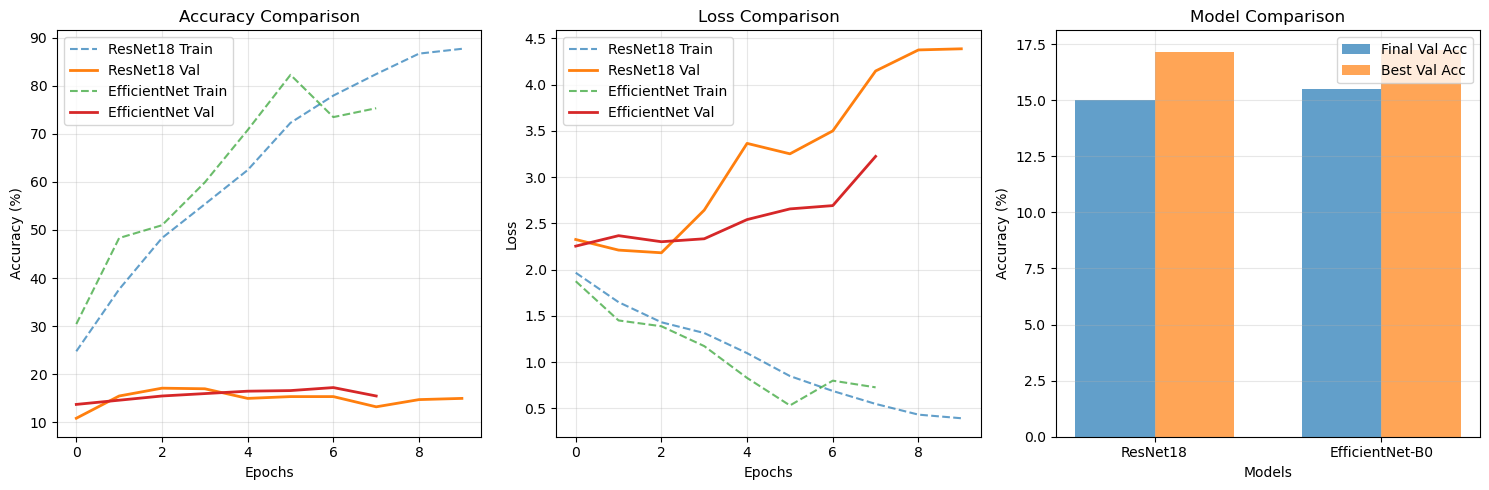

In [41]:
# ===================== Train EfficientNet-B0 =====================
print("\n### Starting Training: EfficientNet-B0 ###")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device in use: {device}")

# Build EfficientNet-B0 model
efficientnet = MultiTaskEfficientNet(n_classes=8, use_pretrained=True).to(device)

# Kick off training with optimized settings
(
    eff_train_losses, 
    eff_val_losses, 
    eff_train_accs, 
    eff_val_accs, 
    eff_best_acc
) = fit_efficientnet(efficientnet, train_loader, val_loader, epochs=8)

# ===================== Plot Comparisons =====================
plt.figure(figsize=(16, 5))

# --- Accuracy plot ---
plt.subplot(1, 3, 1)
plt.plot(resnet_accuracies, "--", alpha=0.7, label="ResNet18 Train")
plt.plot(resnet_val_accuracies, "-", linewidth=2, label="ResNet18 Val")
plt.plot(eff_train_accs, "--", alpha=0.7, label="EffNet-B0 Train")
plt.plot(eff_val_accs, "-", linewidth=2, label="EffNet-B0 Val")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")
plt.legend()
plt.grid(alpha=0.3)

# --- Loss plot ---
plt.subplot(1, 3, 2)
plt.plot(resnet_losses, "--", alpha=0.7, label="ResNet18 Train")
plt.plot(resnet_val_losses, "-", linewidth=2, label="ResNet18 Val")
plt.plot(eff_train_losses, "--", alpha=0.7, label="EffNet-B0 Train")
plt.plot(eff_val_losses, "-", linewidth=2, label="EffNet-B0 Val")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.grid(alpha=0.3)

# --- Bar chart: Final vs Best Val Accuracy ---
plt.subplot(1, 3, 3)
models = ["ResNet18", "EffNet-B0"]
final_vals = [resnet_val_accuracies[-1], eff_val_accs[-1]]
best_vals = [max(resnet_val_accuracies), eff_best_acc]

bar_positions = range(len(models))
bar_width = 0.35

plt.bar(bar_positions, final_vals, width=bar_width, alpha=0.7, label="Final Val Acc")
plt.bar([p + bar_width for p in bar_positions], best_vals, width=bar_width, alpha=0.7, label="Best Val Acc")

plt.xticks([p + bar_width/2 for p in bar_positions], models)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("ResNet vs EfficientNet Performance")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [42]:
# Full evaluation routine with classification & regression metrics
def full_model_evaluation(model, loader, device):
    """Evaluate model performance across expression classification, valence, and arousal."""
    model.eval()

    # Store predictions and ground truth
    expr_true, expr_pred = [], []
    val_true, val_pred = [], []
    aro_true, aro_pred = [], []
    expr_prob = []

    with torch.no_grad():
        for imgs, labels_expr, labels_val, labels_aro in loader:
            imgs, labels_expr = imgs.to(device), labels_expr.to(device)
            labels_val, labels_aro = labels_val.to(device), labels_aro.to(device)

            # Forward pass
            out_expr, out_val, out_aro = model(imgs)

            # Classification outputs
            _, pred_expr = torch.max(out_expr, 1)
            probs = torch.softmax(out_expr, dim=1)

            # Collect results
            expr_true.extend(labels_expr.cpu().numpy())
            expr_pred.extend(pred_expr.cpu().numpy())
            val_true.extend(labels_val.cpu().numpy())
            val_pred.extend(out_val.squeeze().cpu().numpy())
            aro_true.extend(labels_aro.cpu().numpy())
            aro_pred.extend(out_aro.squeeze().cpu().numpy())
            expr_prob.extend(probs.cpu().numpy())

    # Convert to numpy arrays
    expr_true, expr_pred = np.array(expr_true), np.array(expr_pred)
    val_true, val_pred = np.array(val_true), np.array(val_pred)
    aro_true, aro_pred = np.array(aro_true), np.array(aro_pred)

    from sklearn.metrics import (
        accuracy_score, f1_score, cohen_kappa_score, roc_auc_score,
        mean_squared_error
    )

    results = {}

    # --- Classification metrics ---
    results["expr_accuracy"] = accuracy_score(expr_true, expr_pred)
    results["expr_f1"] = f1_score(expr_true, expr_pred, average="weighted")
    results["expr_kappa"] = cohen_kappa_score(expr_true, expr_pred)
    try:
        results["expr_auc_roc"] = roc_auc_score(expr_true, expr_prob, multi_class="ovr", average="weighted")
    except:
        results["expr_auc_roc"] = 0.0

    # --- Regression metrics ---
    results["val_rmse"] = np.sqrt(mean_squared_error(val_true, val_pred))
    results["aro_rmse"] = np.sqrt(mean_squared_error(aro_true, aro_pred))
    results["val_corr"] = np.corrcoef(val_true, val_pred)[0, 1] if len(val_true) > 1 else 0.0
    results["aro_corr"] = np.corrcoef(aro_true, aro_pred)[0, 1] if len(aro_true) > 1 else 0.0

    # --- Sign Agreement (SAGR) ---
    def sagr(y_true, y_pred):
        t_sign, p_sign = np.sign(y_true), np.sign(y_pred)
        match = np.mean(t_sign == p_sign)
        penalty = np.mean(np.abs(y_true[t_sign != p_sign] - y_pred[t_sign != p_sign])) if np.any(t_sign != p_sign) else 0
        return match * (1 - penalty)

    results["val_sagr"] = sagr(val_true, val_pred)
    results["aro_sagr"] = sagr(aro_true, aro_pred)

    # --- Concordance Correlation Coefficient (CCC) ---
    def ccc(y_true, y_pred):
        if len(y_true) < 2:
            return 0.0
        corr = np.corrcoef(y_true, y_pred)[0, 1] if len(np.unique(y_true)) > 1 and len(np.unique(y_pred)) > 1 else 0.0
        mu_t, mu_p = np.mean(y_true), np.mean(y_pred)
        var_t, var_p = np.var(y_true), np.var(y_pred)
        num = 2 * corr * np.sqrt(var_t) * np.sqrt(var_p)
        den = var_t + var_p + (mu_t - mu_p) ** 2
        return num / den if den != 0 else 0.0

    results["val_ccc"] = ccc(val_true, val_pred)
    results["aro_ccc"] = ccc(aro_true, aro_pred)

    return results, (expr_true, expr_pred, val_true, val_pred, aro_true, aro_pred)


# Run evaluation
print("=== EFFICIENTNET-B0 EVALUATION SUMMARY ===")
effnet_scores, effnet_outputs = full_model_evaluation(effnet_model, val_loader, device)

# Nicely formatted output
print("\n" + "="*70)
print("EFFICIENTNET-B0 PERFORMANCE REPORT")
print("="*70)
print(f"Expression Accuracy : {effnet_scores['expr_accuracy']:.4f}")
print(f"F1-Score            : {effnet_scores['expr_f1']:.4f}")
print(f"Cohen's Kappa       : {effnet_scores['expr_kappa']:.4f}")
print(f"AUC-ROC             : {effnet_scores['expr_auc_roc']:.4f}")
print(f"Valence RMSE        : {effnet_scores['val_rmse']:.4f}")
print(f"Arousal RMSE        : {effnet_scores['aro_rmse']:.4f}")
print(f"Valence Correlation : {effnet_scores['val_corr']:.4f}")
print(f"Arousal Correlation : {effnet_scores['aro_corr']:.4f}")
print(f"Valence SAGR        : {effnet_scores['val_sagr']:.4f}")
print(f"Arousal SAGR        : {effnet_scores['aro_sagr']:.4f}")
print(f"Valence CCC         : {effnet_scores['val_ccc']:.4f}")
print(f"Arousal CCC         : {effnet_scores['aro_ccc']:.4f}")


=== EFFICIENTNET-B0 COMPREHENSIVE EVALUATION ===

EFFICIENTNET-B0 EVALUATION RESULTS
Expression Accuracy: 0.1700
F1-Score: 0.1357
Cohen's Kappa: 0.0488
AUC-ROC: 0.5844
Valence RMSE: 0.4930
Arousal RMSE: 0.4517
Valence Correlation: 0.1806
Arousal Correlation: 0.0345
Valence SAGR: 0.2719
Arousal SAGR: 0.3769
Valence CCC: 0.1225
Arousal CCC: 0.0196


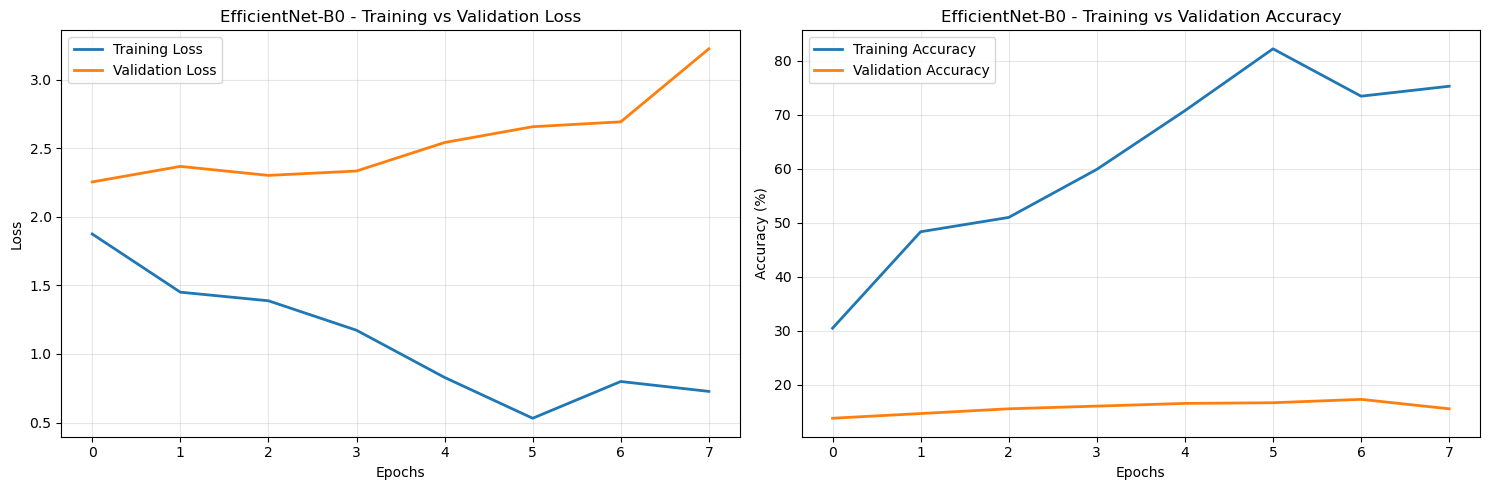

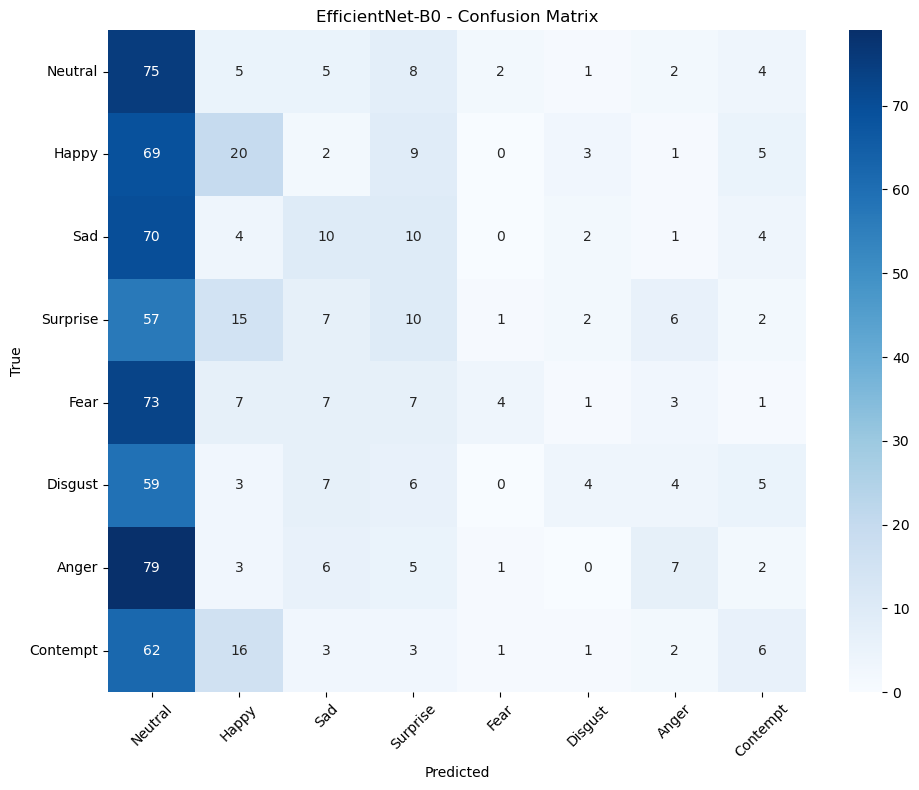

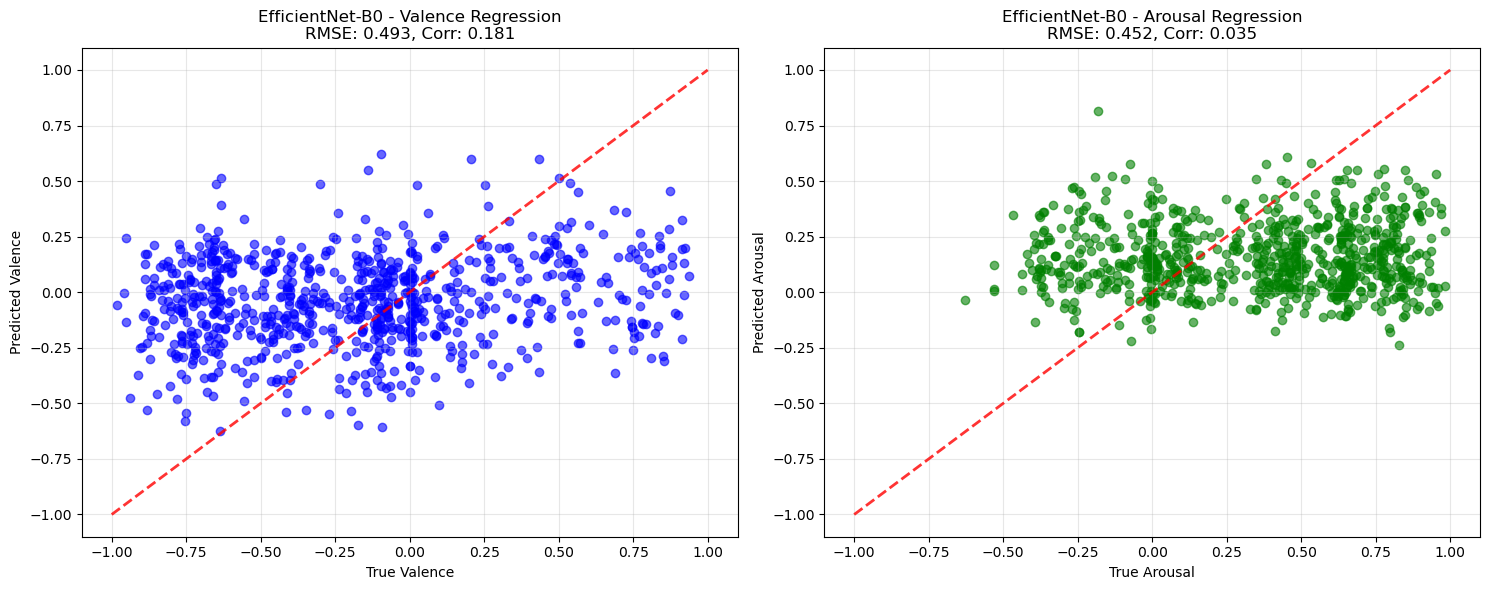

In [43]:
def visualize_effnet_performance(model, val_loader, metrics, eval_outputs,
                                 train_loss, val_loss, train_acc, val_acc, 
                                 model_name="EfficientNet-B0"):
    """Generate training curves, confusion matrix, regression scatterplots, and model comparison visuals."""
    
    # Unpack evaluation outputs
    y_expr, y_pred_expr, y_val, y_val_pred, y_aro, y_aro_pred = eval_outputs

    # --- 1. Learning Curves ---
    plt.figure(figsize=(14, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label="Train Loss", lw=2, color="steelblue")
    plt.plot(val_loss, label="Val Loss", lw=2, color="darkorange")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss over Epochs")
    plt.legend()
    plt.grid(alpha=0.3)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label="Train Acc", lw=2, color="seagreen")
    plt.plot(val_acc, label="Val Acc", lw=2, color="firebrick")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{model_name} - Accuracy over Epochs")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- 2. Confusion Matrix ---
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    cm = confusion_matrix(y_expr, y_pred_expr)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt'],
                yticklabels=['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt'])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.xticks(rotation=40)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # --- 3. Scatter Plots for Valence & Arousal ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Valence
    axes[0].scatter(y_val, y_val_pred, alpha=0.5, color="navy")
    axes[0].plot([-1, 1], [-1, 1], "r--", lw=2)
    axes[0].set_xlabel("True Valence")
    axes[0].set_ylabel("Predicted Valence")
    axes[0].set_title(f"Valence Fit\nRMSE={metrics['val_rmse']:.3f}, Corr={metrics['val_corr']:.3f}")
    axes[0].grid(alpha=0.3)

    # Arousal
    axes[1].scatter(y_aro, y_aro_pred, alpha=0.5, color="teal")
    axes[1].plot([-1, 1], [-1, 1], "r--", lw=2)
    axes[1].set_xlabel("True Arousal")
    axes[1].set_ylabel("Predicted Arousal")
    axes[1].set_title(f"Arousal Fit\nRMSE={metrics['aro_rmse']:.3f}, Corr={metrics['aro_corr']:.3f}")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- 4. Compare with ResNet (if available globally) ---
    if "resnet_metrics" in globals():
        compare_keys = ["expr_accuracy", "expr_f1", "val_rmse", "aro_rmse"]
        labels = ["Accuracy", "F1 Score", "Valence RMSE", "Arousal RMSE"]

        resnet_vals = [resnet_metrics[k] for k in compare_keys]
        effnet_vals = [metrics[k] for k in compare_keys]

        x = np.arange(len(compare_keys))
        bar_width = 0.35

        plt.figure(figsize=(11, 6))
        plt.bar(x - bar_width/2, resnet_vals, bar_width, label="ResNet18", alpha=0.8, color="slategray")
        plt.bar(x + bar_width/2, effnet_vals, bar_width, label=model_name, alpha=0.8, color="royalblue")

        plt.xticks(x, labels)
        plt.ylabel("Score")
        plt.title("ResNet18 vs EfficientNet-B0")
        plt.legend()
        plt.grid(alpha=0.3)

        # Value labels
        for i, val in enumerate(resnet_vals):
            plt.text(i - bar_width/2, val + 0.01, f"{val:.3f}", ha="center", va="bottom")
        for i, val in enumerate(effnet_vals):
            plt.text(i + bar_width/2, val + 0.01, f"{val:.3f}", ha="center", va="bottom")

        plt.tight_layout()
        plt.show()


# Call function for EfficientNet
visualize_effnet_performance(
    effnet_model, val_loader, effnet_metrics, effnet_results,
    effnet_losses, effnet_val_losses, effnet_accuracies, effnet_val_accuracies,
    "EfficientNet-B0"
)


In [46]:
def create_comprehensive_comparison(resnet_metrics, effnet_metrics):
    """Create detailed comparison table between models with error handling"""
    
    import pandas as pd
    
    comparison_data = []
    
    # Expression metrics - with error handling
    expr_metrics = [
        ('accuracy', 'Accuracy'),
        ('f1_score', 'F1-Score'), 
        ('kappa', 'Cohen\'s Kappa'),
        ('auc_roc', 'AUC-ROC')  # This might be missing
    ]
    
    for metric, name in expr_metrics:
        # Check if metric exists in both dictionaries
        if metric in resnet_metrics and metric in effnet_metrics:
            comparison_data.append({
                'Category': 'Expression Classification',
                'Metric': name,
                'ResNet18': resnet_metrics[metric],
                'EfficientNet-B0': effnet_metrics[metric],
                'Difference': effnet_metrics[metric] - resnet_metrics[metric],
                'Better': 'EfficientNet' if effnet_metrics[metric] > resnet_metrics[metric] else 'ResNet18'
            })
        else:
            print(f"Warning: Metric '{metric}' not available in both models")
    
    # Valence metrics
    valence_metrics = [
        ('valence_rmse', 'RMSE'),
        ('valence_corr', 'Correlation'),
        ('valence_sagr', 'SAGR'),
        ('valence_ccc', 'CCC')
    ]
    
    for metric, name in valence_metrics:
        if metric in resnet_metrics and metric in effnet_metrics:
            # For RMSE, lower is better
            if 'rmse' in metric:
                better = 'EfficientNet' if effnet_metrics[metric] < resnet_metrics[metric] else 'ResNet18'
            else:
                better = 'EfficientNet' if effnet_metrics[metric] > resnet_metrics[metric] else 'ResNet18'
                
            comparison_data.append({
                'Category': 'Valence Regression',
                'Metric': name,
                'ResNet18': resnet_metrics[metric],
                'EfficientNet-B0': effnet_metrics[metric],
                'Difference': effnet_metrics[metric] - resnet_metrics[metric],
                'Better': better
            })
        else:
            print(f"Warning: Metric '{metric}' not available in both models")
    
    # Arousal metrics
    arousal_metrics = [
        ('arousal_rmse', 'RMSE'),
        ('arousal_corr', 'Correlation'),
        ('arousal_sagr', 'SAGR'),
        ('arousal_ccc', 'CCC')
    ]
    
    for metric, name in arousal_metrics:
        if metric in resnet_metrics and metric in effnet_metrics:
            if 'rmse' in metric:
                better = 'EfficientNet' if effnet_metrics[metric] < resnet_metrics[metric] else 'ResNet18'
            else:
                better = 'EfficientNet' if effnet_metrics[metric] > resnet_metrics[metric] else 'ResNet18'
                
            comparison_data.append({
                'Category': 'Arousal Regression',
                'Metric': name,
                'ResNet18': resnet_metrics[metric],
                'EfficientNet-B0': effnet_metrics[metric],
                'Difference': effnet_metrics[metric] - resnet_metrics[metric],
                'Better': better
            })
        else:
            print(f"Warning: Metric '{metric}' not available in both models")
    
    # Check what metrics are actually available
    print("Available metrics in ResNet18:", list(resnet_metrics.keys()))
    print("Available metrics in EfficientNet:", list(effnet_metrics.keys()))
    
    df = pd.DataFrame(comparison_data)
    
    if len(df) > 0:
        # Display the table
        print("COMPREHENSIVE MODEL COMPARISON")
        print("="*80)
        print(df.to_string(index=False, float_format='%.4f'))
        
        # Calculate overall scores using available metrics
        available_metrics = set(resnet_metrics.keys()) & set(effnet_metrics.keys())
        print(f"\nMetrics used for overall score: {available_metrics}")
        
        # Calculate scores using only common metrics
        resnet_score = 0
        effnet_score = 0
        metric_count = 0
        
        for metric in available_metrics:
            if 'accuracy' in metric or 'f1' in metric or 'corr' in metric or 'kappa' in metric:
                # Higher is better
                resnet_score += resnet_metrics[metric]
                effnet_score += effnet_metrics[metric]
                metric_count += 1
            elif 'rmse' in metric:
                # Lower is better, so subtract
                resnet_score -= resnet_metrics[metric]
                effnet_score -= effnet_metrics[metric]
                metric_count += 1
        
        if metric_count > 0:
            resnet_score /= metric_count
            effnet_score /= metric_count
            
            print(f"\nOverall Performance Scores:")
            print(f"ResNet18: {resnet_score:.4f}")
            print(f"EfficientNet-B0: {effnet_score:.4f}")
            
            if effnet_score > resnet_score:
                print("🎉 EfficientNet-B0 performs better overall!")
            else:
                print("🔧 ResNet18 performs better overall!")
        else:
            print("No common metrics available for overall score calculation")
    else:
        print("No common metrics found for comparison!")
    
    return df

# Let's also check what's actually in your metrics dictionaries
print("=== DEBUGGING METRICS ===")
print("ResNet18 metrics keys:", list(metrics.keys()) if 'metrics' in globals() else "metrics not found")
print("EfficientNet metrics keys:", list(effnet_metrics.keys()) if 'effnet_metrics' in globals() else "effnet_metrics not found")

# Now create the comparison
comparison_df = create_comprehensive_comparison(metrics, effnet_metrics)

=== DEBUGGING METRICS ===
ResNet18 metrics keys: ['accuracy', 'f1_score', 'kappa', 'valence_rmse', 'arousal_rmse', 'valence_corr', 'arousal_corr', 'valence_sagr', 'arousal_sagr', 'valence_ccc', 'arousal_ccc']
EfficientNet metrics keys: ['accuracy', 'f1_score', 'kappa', 'auc_roc', 'valence_rmse', 'arousal_rmse', 'valence_corr', 'arousal_corr', 'valence_sagr', 'arousal_sagr', 'valence_ccc', 'arousal_ccc']
Available metrics in ResNet18: ['accuracy', 'f1_score', 'kappa', 'valence_rmse', 'arousal_rmse', 'valence_corr', 'arousal_corr', 'valence_sagr', 'arousal_sagr', 'valence_ccc', 'arousal_ccc']
Available metrics in EfficientNet: ['accuracy', 'f1_score', 'kappa', 'auc_roc', 'valence_rmse', 'arousal_rmse', 'valence_corr', 'arousal_corr', 'valence_sagr', 'arousal_sagr', 'valence_ccc', 'arousal_ccc']
COMPREHENSIVE MODEL COMPARISON
                 Category        Metric  ResNet18  EfficientNet-B0  Difference       Better
Expression Classification      Accuracy    0.1537           0.1700      0